# Capítulo 18 — Validación cruzada

En los cuadernos anteriores evaluamos modelos mediante una separación entre entrenamiento y prueba. Esa estrategia es fundamental, pero una sola división puede ofrecer una imagen demasiado dependiente de los casos que quedaron en cada conjunto.

En este cuaderno usaremos **validación cruzada** para obtener varias mediciones del desempeño. Observaremos los folds, compararemos K-Fold con Stratified K-Fold y resumiremos los resultados mediante su promedio y su variabilidad.

También aplicaremos el procedimiento a clasificación y regresión, compararemos modelos conocidos bajo las mismas condiciones y comprobaremos por qué el preprocesamiento debe permanecer dentro del pipeline.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar por qué una única separación train/test puede ser insuficiente;
- describir el funcionamiento de K-Fold Cross Validation;
- reconocer que la validación cruzada entrena varios modelos temporales;
- aplicar Stratified K-Fold en clasificación;
- calcular e interpretar el promedio y la desviación estándar de una métrica;
- comparar modelos usando las mismas divisiones y la misma métrica;
- interpretar la convención de errores negativos de `scikit-learn`;
- evaluar un pipeline completo sin ajustar el preprocesamiento con datos de validación;
- distinguir el uso de la validación cruzada del uso del conjunto de prueba final.

La búsqueda sistemática de hiperparámetros se desarrollará en el capítulo siguiente.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para organizar los resultados, Matplotlib para visualizarlos y `scikit-learn` para construir los folds, evaluar modelos y preparar pipelines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

plt.rcParams["figure.dpi"] = 110


## 2. Comprobar la limitación de un único split

Continuaremos con el dataset **Breast Cancer Wisconsin**, utilizado en los cuadernos 11, 12 y 13. Cada fila contiene mediciones obtenidas a partir de imágenes digitalizadas de muestras celulares.

Mantendremos la convención de esos cuadernos:

- `0`: caso benigno;
- `1`: caso maligno.

La clase positiva representa, por lo tanto, el caso que queremos detectar.

> Este dataset se utiliza exclusivamente con fines educativos. Los resultados del cuaderno no constituyen una herramienta médica ni deben usarse para tomar decisiones clínicas.


In [2]:
datos_medicos = load_breast_cancer(as_frame=True)

X = datos_medicos.data

# En el dataset original, 0 significa maligno y 1 benigno.
# Invertimos las etiquetas para conservar la convención de los cuadernos previos.
y = 1 - datos_medicos.target
y.name = "caso_maligno"

pd.DataFrame({
    "filas": [len(X)],
    "variables": [X.shape[1]],
    "casos_benignos": [(y == 0).sum()],
    "casos_malignos": [(y == 1).sum()],
})


,filas,variables,casos_benignos,casos_malignos
0,569,30,357,212


Antes de comenzar las comparaciones, reservaremos un **conjunto de prueba final**. La validación cruzada se aplicará únicamente al conjunto de desarrollo. Así, el test no participará en la comparación de modelos.


In [3]:
X_desarrollo, X_test_final, y_desarrollo, y_test_final = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=18,
    stratify=y,
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [len(X_desarrollo), len(X_test_final)],
    "proporcion_malignos": [
        y_desarrollo.mean(),
        y_test_final.mean(),
    ],
}).round(3)


,conjunto,filas,proporcion_malignos
0,Desarrollo,455,0.374
1,Prueba final,114,0.368


Para observar la sensibilidad de una única separación, dividiremos el conjunto de desarrollo diez veces. En todos los casos entrenaremos el mismo pipeline de regresión logística y calcularemos F1-score sobre la parte de validación.

Solo cambiaremos `random_state`: el modelo, las variables, el tamaño de los conjuntos y la métrica permanecerán iguales.


In [4]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=3000)),
])

resultados_splits = []

for semilla in range(10):
    X_train, X_validacion, y_train, y_validacion = train_test_split(
        X_desarrollo,
        y_desarrollo,
        test_size=0.25,
        random_state=semilla,
        stratify=y_desarrollo,
    )

    modelo_logistico.fit(X_train, y_train)
    pred_validacion = modelo_logistico.predict(X_validacion)

    resultados_splits.append({
        "semilla": semilla,
        "F1": f1_score(y_validacion, pred_validacion),
    })

resultados_splits = pd.DataFrame(resultados_splits)
resultados_splits.round(4)


,semilla,F1
0,0,0.9398
1,1,1.0000
2,2,0.9762
3,3,0.9882
4,4,0.9412
5,5,0.9762
6,6,0.9250
7,7,0.9882
8,8,0.9286
9,9,0.9762


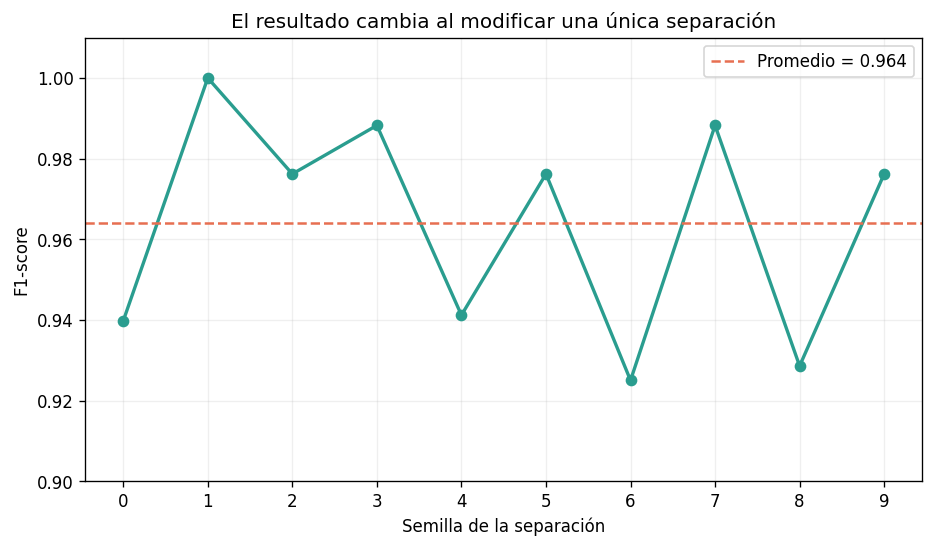

In [5]:
plt.figure(figsize=(9, 4.8))
plt.plot(
    resultados_splits["semilla"],
    resultados_splits["F1"],
    marker="o",
    linewidth=2,
    color="#2A9D8F",
)
plt.axhline(
    resultados_splits["F1"].mean(),
    color="#E76F51",
    linestyle="--",
    label=f"Promedio = {resultados_splits['F1'].mean():.3f}",
)
plt.xticks(resultados_splits["semilla"])
plt.ylim(0.90, 1.01)
plt.xlabel("Semilla de la separación")
plt.ylabel("F1-score")
plt.title("El resultado cambia al modificar una única separación")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


El F1-score cambia entre **0,925 y 1,000**, aunque el modelo y los datos disponibles son los mismos. Una sola de estas divisiones podría hacernos juzgar al modelo de forma demasiado optimista o pesimista.

La validación cruzada no elimina toda incertidumbre, pero reduce la dependencia de una única partición y permite observar cuánta variabilidad existe.


## 3. Comprender K-Fold Cross Validation

K-Fold divide los datos en `K` partes aproximadamente iguales. En cada repetición:

1. un fold se usa para validar;
2. los folds restantes se usan para entrenar;
3. el procedimiento continúa hasta que todos los folds hayan sido usados una vez como validación.

Construiremos un ejemplo pequeño con veinte casos y cinco folds para ver el recorrido completo.


In [6]:
casos = np.arange(1, 21)
cv_demostracion = KFold(n_splits=5, shuffle=False)

filas_folds = []
matriz_folds = np.zeros((5, len(casos)), dtype=int)

for numero_fold, (indices_train, indices_validacion) in enumerate(
    cv_demostracion.split(casos),
    start=1,
):
    matriz_folds[numero_fold - 1, indices_validacion] = 1

    filas_folds.append({
        "fold": numero_fold,
        "casos_para_entrenar": len(indices_train),
        "casos_para_validar": len(indices_validacion),
        "ids_en_validacion": ", ".join(
            map(str, casos[indices_validacion])
        ),
    })

tabla_folds = pd.DataFrame(filas_folds)
tabla_folds


,fold,casos_para_entrenar,casos_para_validar,ids_en_validacion
0,1,16,4,"1, 2, 3, 4"
1,2,16,4,"5, 6, 7, 8"
2,3,16,4,"9, 10, 11, 12"
3,4,16,4,"13, 14, 15, 16"
4,5,16,4,"17, 18, 19, 20"


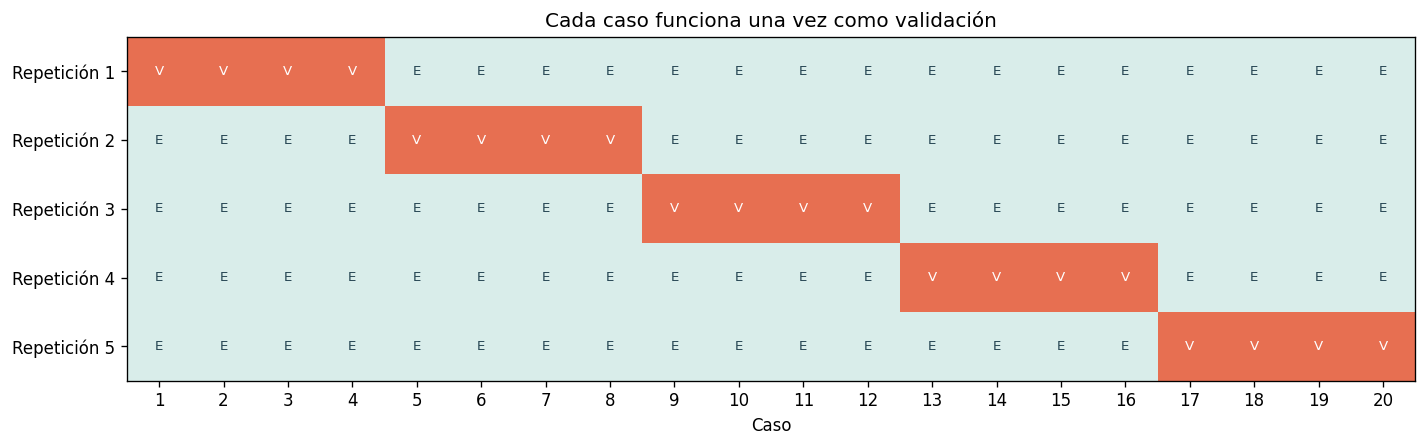

In [7]:
colores_folds = ListedColormap(["#D9EDEA", "#E76F51"])

plt.figure(figsize=(12, 3.8))
plt.imshow(
    matriz_folds,
    aspect="auto",
    cmap=colores_folds,
    vmin=0,
    vmax=1,
)
plt.xticks(
    np.arange(len(casos)),
    casos,
)
plt.yticks(
    np.arange(5),
    [f"Repetición {i}" for i in range(1, 6)],
)
plt.xlabel("Caso")
plt.title("Cada caso funciona una vez como validación")

for fila in range(5):
    for columna in range(len(casos)):
        texto = "V" if matriz_folds[fila, columna] else "E"
        color = "white" if texto == "V" else "#264653"
        plt.text(
            columna,
            fila,
            texto,
            ha="center",
            va="center",
            color=color,
            fontsize=8,
        )

plt.tight_layout()
plt.show()


En el gráfico:

- `E` indica que el caso se usa para entrenar;
- `V` indica que el caso se usa para validar.

Con cinco folds se realizan **cinco entrenamientos temporales**. La validación cruzada no produce un único modelo definitivo: produce varias evaluaciones que permiten estimar el desempeño esperado. Después de elegir el enfoque, el modelo final puede entrenarse con todos los datos de desarrollo.


## 4. K-Fold y Stratified K-Fold

En clasificación, una división común puede dejar proporciones distintas de las clases en cada fold. Esto resulta especialmente problemático cuando una clase es minoritaria.

Crearemos cien etiquetas: ochenta casos de clase `0` y veinte de clase `1`. Compararemos K-Fold con mezcla aleatoria frente a Stratified K-Fold usando la misma cantidad de folds.


In [8]:
X_demo = np.arange(100).reshape(-1, 1)
y_demo = np.array([0] * 80 + [1] * 20)

estrategias = {
    "K-Fold": KFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    ),
    "Stratified K-Fold": StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    ),
}

distribuciones = []

for nombre, estrategia in estrategias.items():
    for fold, (_, indices_validacion) in enumerate(
        estrategia.split(X_demo, y_demo),
        start=1,
    ):
        y_fold = y_demo[indices_validacion]
        distribuciones.append({
            "estrategia": nombre,
            "fold": fold,
            "clase_0": (y_fold == 0).sum(),
            "clase_1": (y_fold == 1).sum(),
            "proporcion_clase_1": y_fold.mean(),
        })

distribuciones = pd.DataFrame(distribuciones)
distribuciones


,estrategia,fold,clase_0,clase_1,proporcion_clase_1
0,K-Fold,1,17,3,0.15
1,K-Fold,2,16,4,0.20
2,K-Fold,3,17,3,0.15
3,K-Fold,4,16,4,0.20
4,K-Fold,5,14,6,0.30
5,Stratified K-Fold,1,16,4,0.20
6,Stratified K-Fold,2,16,4,0.20
7,Stratified K-Fold,3,16,4,0.20
8,Stratified K-Fold,4,16,4,0.20
9,Stratified K-Fold,5,16,4,0.20


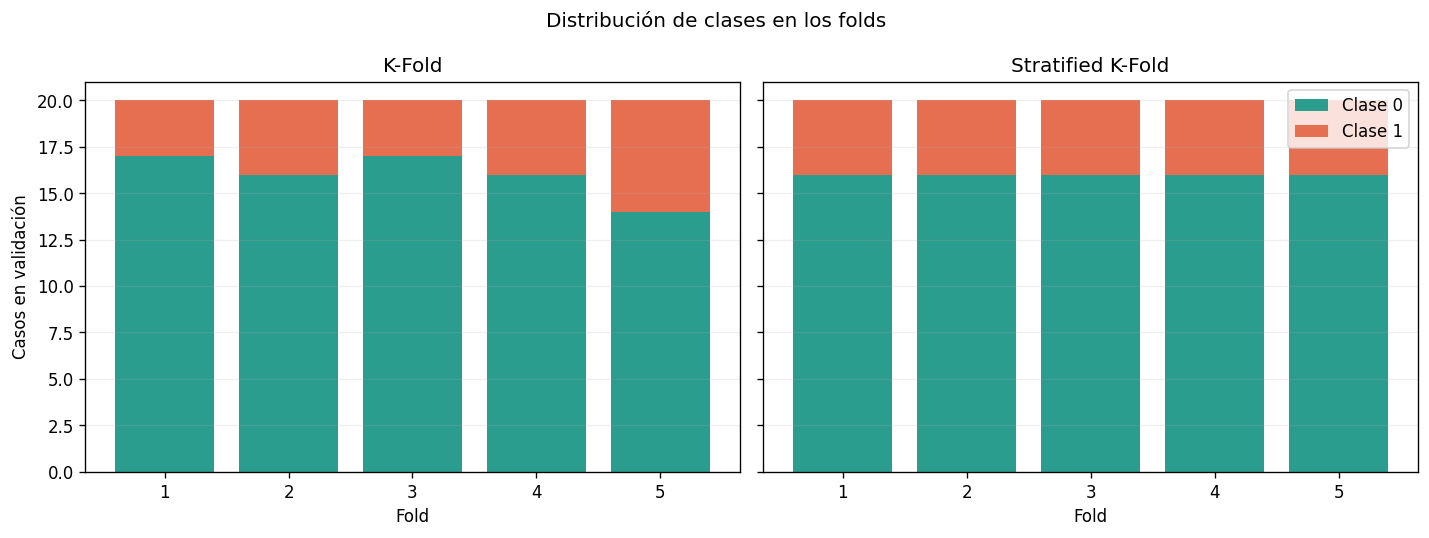

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, nombre in zip(axes, estrategias):
    datos_grafico = distribuciones[
        distribuciones["estrategia"] == nombre
    ]

    ax.bar(
        datos_grafico["fold"],
        datos_grafico["clase_0"],
        color="#2A9D8F",
        label="Clase 0",
    )
    ax.bar(
        datos_grafico["fold"],
        datos_grafico["clase_1"],
        bottom=datos_grafico["clase_0"],
        color="#E76F51",
        label="Clase 1",
    )
    ax.set_title(nombre)
    ax.set_xlabel("Fold")
    ax.set_xticks(range(1, 6))
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Casos en validación")
axes[1].legend()
fig.suptitle("Distribución de clases en los folds")
plt.tight_layout()
plt.show()


K-Fold deja entre tres y seis positivos en los folds de este ejemplo. Stratified K-Fold conserva exactamente dieciséis casos de clase `0` y cuatro de clase `1` en cada uno.

La estratificación **no balancea las clases ni mejora el modelo**. Solo construye divisiones más representativas. Si la clase minoritaria tiene menos casos que la cantidad de folds, no podrá aparecer en todos ellos.


## 5. Aplicar validación cruzada a clasificación

Evaluaremos cuatro estrategias ya conocidas:

- una referencia que siempre predice la clase mayoritaria;
- regresión logística con escalado;
- KNN con escalado;
- un árbol de decisión con profundidad limitada.

Usaremos F1-score porque la clase positiva es menos frecuente y queremos considerar conjuntamente precision y recall. Todos los modelos recibirán **los mismos cinco folds estratificados**.


In [10]:
cv_clasificacion = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

modelos_clasificacion = {
    "Referencia mayoritaria": DummyClassifier(
        strategy="most_frequent"
    ),
    "Regresión logística": Pipeline(steps=[
        ("escala", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=3000)),
    ]),
    "KNN": Pipeline(steps=[
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=7)),
    ]),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=4,
        random_state=42,
    ),
}


In [11]:
scores_clasificacion = {}

for nombre, modelo in modelos_clasificacion.items():
    scores_clasificacion[nombre] = cross_val_score(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv_clasificacion,
        scoring="f1",
    )

tabla_scores_clasificacion = pd.DataFrame(
    scores_clasificacion,
    index=[f"Fold {i}" for i in range(1, 6)],
)

tabla_scores_clasificacion.round(4)


,Referencia mayoritaria,Regresión logística,KNN,Árbol de decisión
Fold 1,0.0,0.9855,0.9851,0.8919
Fold 2,0.0,0.9697,0.9394,0.8889
Fold 3,0.0,0.9706,0.9394,0.9118
Fold 4,0.0,0.9706,0.9375,0.9412
Fold 5,0.0,0.9697,0.9375,0.9091


In [12]:
resumen_clasificacion = pd.DataFrame({
    "F1_promedio": tabla_scores_clasificacion.mean(),
    "desviacion_estandar": tabla_scores_clasificacion.std(ddof=0),
    "F1_minimo": tabla_scores_clasificacion.min(),
    "F1_maximo": tabla_scores_clasificacion.max(),
}).sort_values(
    "F1_promedio",
    ascending=False,
)

resumen_clasificacion.round(4)


,F1_promedio,desviacion_estandar,F1_minimo,F1_maximo
Regresión logística,0.9732,0.0062,0.9697,0.9855
KNN,0.9478,0.0187,0.9375,0.9851
Árbol de decisión,0.9086,0.0187,0.8889,0.9412
Referencia mayoritaria,0.0000,0.0000,0.0000,0.0000


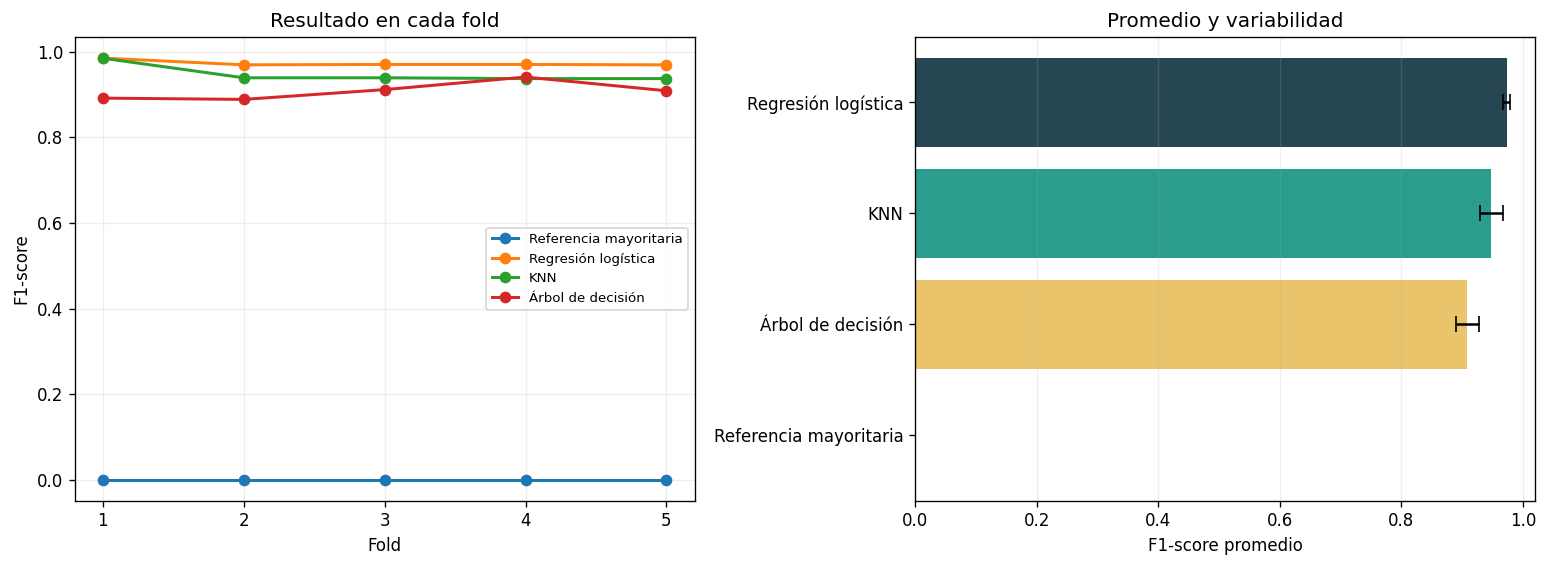

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for nombre in tabla_scores_clasificacion.columns:
    axes[0].plot(
        range(1, 6),
        tabla_scores_clasificacion[nombre],
        marker="o",
        linewidth=1.8,
        label=nombre,
    )

axes[0].set_xticks(range(1, 6))
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("F1-score")
axes[0].set_title("Resultado en cada fold")
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

orden = resumen_clasificacion.index[::-1]
axes[1].barh(
    orden,
    resumen_clasificacion.loc[orden, "F1_promedio"],
    xerr=resumen_clasificacion.loc[orden, "desviacion_estandar"],
    color=["#F4A261", "#E9C46A", "#2A9D8F", "#264653"],
    capsize=5,
)
axes[1].set_xlabel("F1-score promedio")
axes[1].set_title("Promedio y variabilidad")
axes[1].grid(axis="x", alpha=0.2)
axes[1].set_xlim(0, 1.02)

plt.tight_layout()
plt.show()


En esta comparación:

- la referencia mayoritaria obtiene F1 igual a `0`, porque nunca identifica la clase positiva;
- la regresión logística obtiene el mejor promedio, cercano a **0,973**, y la menor variabilidad;
- KNN alcanza un promedio cercano a **0,948**;
- el árbol obtiene aproximadamente **0,909** y presenta más variación entre folds.

La conclusión es ilustrativa para estos datos, esta métrica y estas configuraciones. No demuestra que un algoritmo sea universalmente superior a otro. La comparación es más sólida que la basada en un solo split porque todos los modelos fueron medidos sobre las mismas cinco divisiones.


## 6. Interpretar promedio y variabilidad

El promedio resume el desempeño general estimado. La desviación estándar indica cuánto cambian los resultados entre folds.

Un buen promedio con baja variabilidad suele dar más confianza que el mismo promedio acompañado por resultados muy dispersos. Sin embargo, la desviación estándar no debe usarse como una regla automática: también importa el contexto, el tipo de errores, la simplicidad y la magnitud práctica de las diferencias.


In [14]:
ejemplo_estabilidad = pd.DataFrame({
    "Modelo A": [0.81, 0.83, 0.82, 0.84, 0.82],
    "Modelo B": [0.95, 0.69, 0.74, 0.88, 0.86],
})

pd.DataFrame({
    "promedio": ejemplo_estabilidad.mean(),
    "desviacion_estandar": ejemplo_estabilidad.std(ddof=0),
    "minimo": ejemplo_estabilidad.min(),
    "maximo": ejemplo_estabilidad.max(),
}).round(3)


,promedio,desviacion_estandar,minimo,maximo
Modelo A,0.824,0.010,0.81,0.84
Modelo B,0.824,0.095,0.69,0.95


Los dos modelos del ejemplo tienen el mismo promedio: `0,824`. Sin embargo, el Modelo A es mucho más estable. La media por sí sola habría ocultado esa diferencia.

También conviene revisar folds especialmente malos. Pueden contener casos atípicos, segmentos poco representados o ejemplos difíciles que merecen análisis. La variabilidad no es solamente un número para reportar: también puede orientar el diagnóstico.


## 7. Validación cruzada en regresión

Retomaremos el dataset didáctico de viviendas de los cuadernos 15 y 16. Lo generaremos con la misma semilla para conservar los mismos datos.

Compararemos:

- una referencia que siempre predice el promedio;
- una regresión lineal simple basada en superficie;
- una regresión lineal completa con variables numéricas y barrio.

En este caso usaremos MAE y K-Fold, porque la variable objetivo es continua y no existen clases que estratificar.


In [15]:
rng = np.random.default_rng(15)
n_viviendas = 48

superficie = rng.integers(45, 151, size=n_viviendas)
ambientes_estimados = np.rint(superficie / 25).astype(int)
ambientes = np.clip(
    ambientes_estimados + rng.integers(-1, 2, size=n_viviendas),
    1,
    6,
)
antiguedad = rng.integers(0, 51, size=n_viviendas)
distancia = np.round(rng.uniform(1, 15, size=n_viviendas), 1)
barrio = rng.choice(
    ["Centro", "Norte", "Oeste", "Sur"],
    size=n_viviendas,
)

efecto_barrio = pd.Series(barrio).map({
    "Centro": 18000,
    "Norte": 12000,
    "Oeste": 3000,
    "Sur": -4000,
}).to_numpy()

precio = (
    25000
    + 1050 * superficie
    + 6500 * ambientes
    - 550 * antiguedad
    - 2200 * distancia
    + efecto_barrio
    + rng.normal(0, 7000, size=n_viviendas)
)

viviendas = pd.DataFrame({
    "superficie_m2": superficie,
    "ambientes": ambientes,
    "antiguedad_anios": antiguedad,
    "distancia_centro_km": distancia,
    "barrio": barrio,
    "precio_usd": np.round(precio / 500) * 500,
})

viviendas.head()


,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,barrio,precio_usd
0,143,6,47,3.9,Centro,210500.0
1,118,6,21,6.7,Oeste,154000.0
2,119,6,2,4.7,Norte,184500.0
3,131,6,49,3.8,Oeste,172000.0
4,70,4,47,4.7,Norte,105000.0


El modelo completo necesita tratar de forma diferente las variables numéricas y la variable categórica `barrio`. Usaremos un `ColumnTransformer` dentro de un pipeline:

- las variables numéricas se estandarizan;
- el barrio se convierte mediante One-Hot Encoding;
- la regresión lineal recibe el resultado de ambas transformaciones.

Aunque la regresión lineal no requiere escalado para producir predicciones válidas, lo incluimos para comprobar que cualquier transformación aprendida se ajusta dentro de cada fold.


In [16]:
X_viviendas = viviendas.drop(columns="precio_usd")
y_viviendas = viviendas["precio_usd"]

variables_numericas = [
    "superficie_m2",
    "ambientes",
    "antiguedad_anios",
    "distancia_centro_km",
]
variables_categoricas = ["barrio"]

preparacion = ColumnTransformer(transformers=[
    (
        "numericas",
        Pipeline(steps=[
            ("escalado", StandardScaler()),
        ]),
        variables_numericas,
    ),
    (
        "categoricas",
        OneHotEncoder(handle_unknown="ignore"),
        variables_categoricas,
    ),
])

pipeline_regresion = Pipeline(steps=[
    ("preparacion", preparacion),
    ("modelo", LinearRegression()),
])

modelo_regresion_simple = Pipeline(steps=[
    ("escalado", StandardScaler()),
    ("modelo", LinearRegression()),
])

cv_regresion = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


### La convención de los errores negativos

`cross_val_score` está diseñado para que un valor mayor represente un resultado mejor. Como en MAE un valor menor es mejor, `scikit-learn` usa el nombre `neg_mean_absolute_error` y devuelve el MAE con signo negativo.

Mostraremos primero el valor que entrega la función y luego cambiaremos su signo para recuperar el error en dólares.


In [17]:
scores_mae_negativos = cross_val_score(
    pipeline_regresion,
    X_viviendas,
    y_viviendas,
    cv=cv_regresion,
    scoring="neg_mean_absolute_error",
)

tabla_convencion_mae = pd.DataFrame({
    "fold": range(1, 6),
    "valor_devuelto": scores_mae_negativos,
    "MAE_en_USD": -scores_mae_negativos,
})

tabla_convencion_mae.round(2)


,fold,valor_devuelto,MAE_en_USD
0,1,-4959.14,4959.14
1,2,-5649.52,5649.52
2,3,-5732.38,5732.38
3,4,-5945.74,5945.74
4,5,-9993.48,9993.48


Los valores negativos no representan errores reales menores que cero. Son una convención interna. Para interpretar MAE en sus unidades originales, cambiamos el signo:

```python
mae_por_fold = -scores
```


In [18]:
modelos_regresion = {
    "Referencia: promedio": (
        DummyRegressor(strategy="mean"),
        X_viviendas,
    ),
    "Regresión simple": (
        modelo_regresion_simple,
        X_viviendas[["superficie_m2"]],
    ),
    "Regresión completa": (
        pipeline_regresion,
        X_viviendas,
    ),
}

scores_regresion = {}

for nombre, (modelo, variables) in modelos_regresion.items():
    scores_regresion[nombre] = -cross_val_score(
        modelo,
        variables,
        y_viviendas,
        cv=cv_regresion,
        scoring="neg_mean_absolute_error",
    )

tabla_scores_regresion = pd.DataFrame(
    scores_regresion,
    index=[f"Fold {i}" for i in range(1, 6)],
)

tabla_scores_regresion.round(2)


,Referencia: promedio,Regresión simple,Regresión completa
Fold 1,43105.26,13473.13,4959.14
Fold 2,26565.79,21258.53,5649.52
Fold 3,47457.89,16018.52,5732.38
Fold 4,40094.02,17081.20,5945.74
Fold 5,58683.76,16715.22,9993.48


In [19]:
resumen_regresion = pd.DataFrame({
    "MAE_promedio_USD": tabla_scores_regresion.mean(),
    "desviacion_estandar_USD": tabla_scores_regresion.std(ddof=0),
    "MAE_minimo_USD": tabla_scores_regresion.min(),
    "MAE_maximo_USD": tabla_scores_regresion.max(),
}).sort_values("MAE_promedio_USD")

resumen_regresion.round(2)


,MAE_promedio_USD,desviacion_estandar_USD,MAE_minimo_USD,MAE_maximo_USD
Regresión completa,6456.05,1799.37,4959.14,9993.48
Regresión simple,16909.32,2513.32,13473.13,21258.53
Referencia: promedio,43181.35,10432.91,26565.79,58683.76


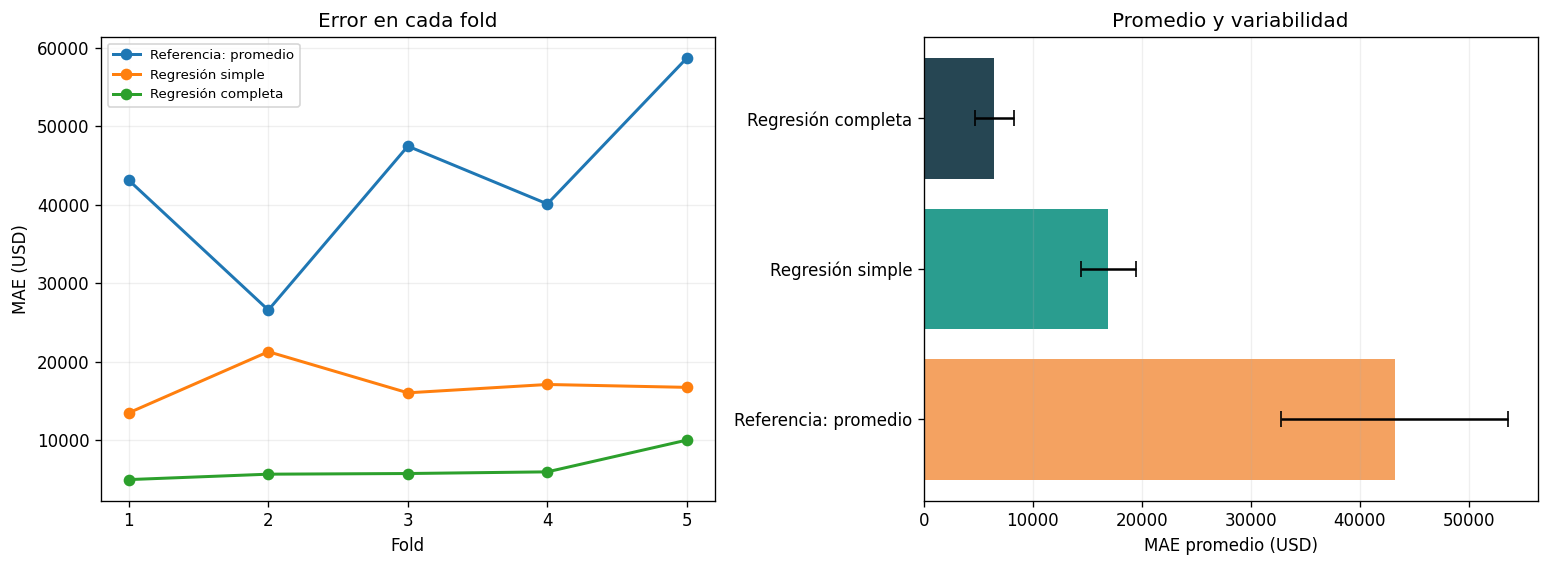

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for nombre in tabla_scores_regresion.columns:
    axes[0].plot(
        range(1, 6),
        tabla_scores_regresion[nombre],
        marker="o",
        linewidth=1.8,
        label=nombre,
    )

axes[0].set_xticks(range(1, 6))
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MAE (USD)")
axes[0].set_title("Error en cada fold")
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

orden_reg = resumen_regresion.index[::-1]
axes[1].barh(
    orden_reg,
    resumen_regresion.loc[orden_reg, "MAE_promedio_USD"],
    xerr=resumen_regresion.loc[
        orden_reg,
        "desviacion_estandar_USD",
    ],
    color=["#F4A261", "#2A9D8F", "#264653"],
    capsize=5,
)
axes[1].set_xlabel("MAE promedio (USD)")
axes[1].set_title("Promedio y variabilidad")
axes[1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


La referencia obtiene un MAE promedio cercano a **USD 43.181**. La regresión simple lo reduce a aproximadamente **USD 16.909**, mientras que el pipeline completo alcanza cerca de **USD 6.456**.

La regresión completa también muestra un fold más difícil, con un MAE cercano a USD 9.993. Esa diferencia aumenta su desviación estándar y recuerda que el promedio no cuenta toda la historia.

En este dataset didáctico, la mejora de la regresión completa es grande y consistente frente a la referencia. Aun así, los valores describen estos datos y esta estrategia de validación; no garantizan el mismo desempeño sobre viviendas reales.


## 8. Comprobar que el preprocesamiento se ajusta dentro del fold

Cuando el pipeline es evaluado mediante validación cruzada, el escalador y el codificador se ajustan solamente con los datos de entrenamiento de cada repetición.

Tomaremos la primera división y compararemos tres promedios de `superficie_m2`:

- el promedio de todos los datos;
- el promedio del conjunto de entrenamiento del primer fold;
- el promedio aprendido por el escalador.


In [21]:
indices_train, indices_validacion = next(
    cv_regresion.split(X_viviendas, y_viviendas)
)

pipeline_regresion.fit(
    X_viviendas.iloc[indices_train],
    y_viviendas.iloc[indices_train],
)

escalador_primer_fold = (
    pipeline_regresion
    .named_steps["preparacion"]
    .named_transformers_["numericas"]
    .named_steps["escalado"]
)

pd.DataFrame({
    "valor": [
        X_viviendas["superficie_m2"].mean(),
        X_viviendas.iloc[indices_train]["superficie_m2"].mean(),
        escalador_primer_fold.mean_[0],
    ],
}, index=[
    "Promedio de todos los datos",
    "Promedio del entrenamiento del fold",
    "Promedio aprendido por StandardScaler",
]).round(4)


,valor
Promedio de todos los datos,102.1458
Promedio del entrenamiento del fold,98.5526
Promedio aprendido por StandardScaler,98.5526


El escalador aprende `98,5526`, exactamente el promedio del conjunto de entrenamiento del fold, y no el promedio global de `102,1458`.

Si hubiéramos escalado todo `X` antes de la validación cruzada, la transformación habría usado información de los casos que luego actuarían como validación. Incluir el preprocesamiento dentro del pipeline mantiene el orden metodológico correcto y ayuda a evitar fuga de datos.


## 9. Usar el conjunto de prueba final

La comparación mediante validación cruzada indicó que la regresión logística fue la alternativa con mejor F1 promedio y menor variabilidad entre los clasificadores evaluados.

Ahora podemos entrenarla con todo el conjunto de desarrollo y usar el test final **una sola vez** para obtener una evaluación independiente.


In [22]:
modelo_final = modelos_clasificacion["Regresión logística"]
modelo_final.fit(X_desarrollo, y_desarrollo)

pred_test_final = modelo_final.predict(X_test_final)
f1_test_final = f1_score(y_test_final, pred_test_final)

pd.DataFrame({
    "evaluacion": ["Validación cruzada", "Prueba final"],
    "F1": [
        resumen_clasificacion.loc[
            "Regresión logística",
            "F1_promedio",
        ],
        f1_test_final,
    ],
}).round(4)


,evaluacion,F1
0,Validación cruzada,0.9732
1,Prueba final,0.9882


El F1-score del test final es aproximadamente **0,988**. Este valor es cercano al obtenido mediante validación cruzada, pero corresponde a una sola evaluación sobre 114 casos.

No deberíamos probar repetidamente nuevas variantes contra este conjunto y elegir la que mejor funcione allí. Si lo hiciéramos, el test comenzaría a influir en nuestras decisiones y dejaría de ser una comprobación independiente.


## 10. Casos que requieren otras divisiones

K-Fold y Stratified K-Fold son apropiados cuando las filas pueden mezclarse razonablemente y representan observaciones independientes. No deben aplicarse de forma automática a cualquier dataset.

| Estructura de los datos | Riesgo de una división común | Cuidado necesario |
|---|---|---|
| Registros ordenados en el tiempo | entrenar con el futuro y validar con el pasado | respetar el orden temporal |
| Varias filas por paciente o cliente | la misma entidad aparece en entrenamiento y validación | mantener cada grupo en una sola parte |
| Clase con menos casos que folds | algunos folds no contienen esa clase | reducir folds o revisar los datos |
| Datos que cambiarán con el tiempo | la evaluación no representa el uso futuro | diseñar una validación acorde al despliegue |

La estrategia de división debe representar cómo recibirá casos nuevos el modelo. Aplicar una función correctamente no garantiza que la evaluación sea metodológicamente válida.


## 11. Actividad breve

La siguiente celda permite cambiar la cantidad de folds y volver a evaluar uno de los modelos conocidos. Trabajaremos únicamente con el conjunto de desarrollo.


In [23]:
numero_folds = 5
modelo_actividad = modelos_clasificacion["KNN"]

cv_actividad = StratifiedKFold(
    n_splits=numero_folds,
    shuffle=True,
    random_state=42,
)

scores_actividad = cross_val_score(
    modelo_actividad,
    X_desarrollo,
    y_desarrollo,
    cv=cv_actividad,
    scoring="f1",
)

pd.DataFrame({
    "F1_promedio": [scores_actividad.mean()],
    "desviacion_estandar": [scores_actividad.std()],
    "F1_minimo": [scores_actividad.min()],
    "F1_maximo": [scores_actividad.max()],
}).round(4)


,F1_promedio,desviacion_estandar,F1_minimo,F1_maximo
0,0.9478,0.0187,0.9375,0.9851


Probá la actividad de esta manera:

1. ejecutá el modelo con 3, 5 y 10 folds;
2. compará el promedio, la desviación estándar y el rango de resultados;
3. repetí la experiencia con regresión logística o árbol de decisión, sin consultar el test final.

Más folds no garantizan automáticamente una mejor evaluación. También aumentan la cantidad de entrenamientos y cambian el tamaño de cada conjunto de validación.


## 12. Síntesis

En este cuaderno:

- comprobamos que una única separación puede producir métricas diferentes;
- representamos el recorrido completo de K-Fold;
- distinguimos K-Fold de Stratified K-Fold;
- evaluamos varios modelos con los mismos folds y la misma métrica;
- resumimos los resultados mediante promedio y desviación estándar;
- interpretamos la convención `neg_mean_absolute_error`;
- validamos pipelines completos para evitar fuga durante el preprocesamiento;
- comparamos modelos contra referencias simples;
- reservamos un conjunto de prueba para la evaluación final;
- reconocimos que los datos temporales o agrupados requieren divisiones especiales.

La validación cruzada mejora la estimación del desempeño, pero no convierte una métrica en una certeza. Las conclusiones siguen dependiendo de la calidad de los datos, la métrica elegida y la correspondencia entre las divisiones y el uso real del modelo.


## Para pensar

1. ¿Por qué dos separaciones train/test pueden producir métricas diferentes aunque el modelo sea el mismo?
2. Si dos modelos tienen el mismo promedio, pero distinta desviación estándar, ¿qué información adicional aporta esa diferencia?
3. ¿Por qué Stratified K-Fold mejora la evaluación de clases desbalanceadas, pero no resuelve el desbalance del modelo?
4. ¿Qué fuga de información puede aparecer si ajustamos un escalador antes de aplicar validación cruzada?
5. ¿Por qué conviene reservar el conjunto de prueba final y no consultarlo después de cada cambio?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
